In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import numpy as np
import pylab as plt
import glob
import os
import scipy.integrate as inte
import scipy.special as special
import scipy.interpolate as interp
import scipy.signal as sig
import scipy.optimize as opt


In [12]:
#import stephane.tools.Smath as smath

#import sympy #symoblic python
import glob
import csv
import os

import shapefile
from pprint import pprint

import icewave.tools.rw_data as rw
import icewave.tools.datafolders as df
import icewave.display.graphes as graphes

import icewave.s

In [13]:
date = '0211'
base = f'/Users/stephane/Documents/BicWin2024/Saguenay/FSD/'
filelist = glob.glob(base+'*.shp')
filename = filelist[0]
print(filename)

/Users/stephane/Documents/BicWin2024/Saguenay/FSD/FSD.shp


In [14]:
savefolder = base+'Results/'
#os.makedirs(savefolder)

In [15]:
sf = shapefile.Reader(filename)

In [21]:
shapes = sf.shapes()
print(len(shapes))

2684


In [26]:
import icewave.gps.gps as gps
import icewave.tools.maths as maths

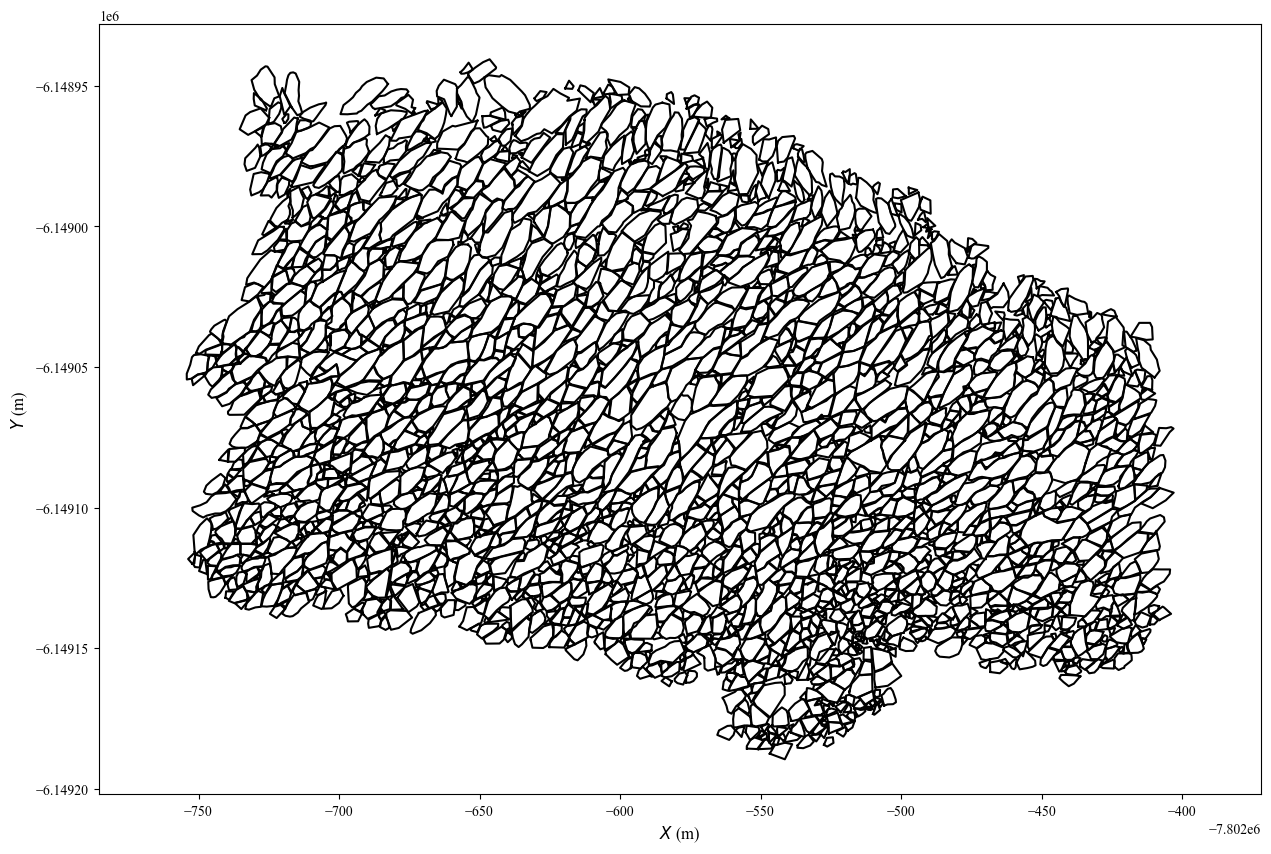

In [52]:
fig,ax = plt.subplots(figsize=(15,10))

for shape in shapes:   
    oid = shape.oid
    points = np.asarray(shape.points)
    X,Y = gps.project(points[:,0],points[:,1],meter=True)
    corners = np.transpose(np.asarray([X-X[0],Y-Y[0]]))
    #Area =     
    #print(corners)
    shapes[oid].Area = maths.PolygonArea(corners) 
    shapes[oid].Xc = np.mean(X)
    shapes[oid].Yc = np.mean(Y)

    ax.plot(X,-Y,'k')
    
plt.axis('equal')
figs = graphes.legende('$X$ (m)','$Y$ (m)','')
graphes.save_figs(figs,savedir=savefolder)
    #print(sphere.PolygonArea(corners))

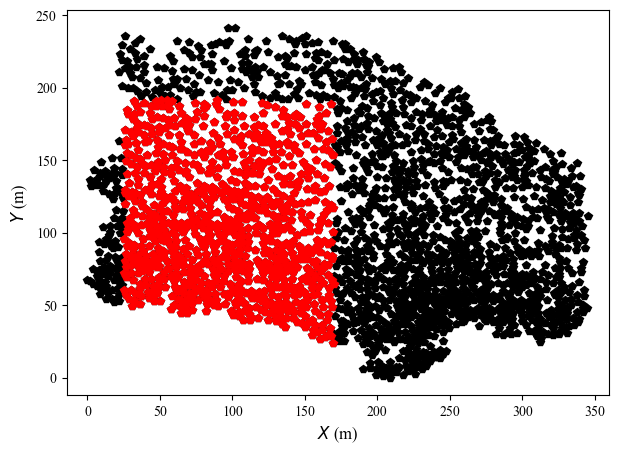

In [53]:
fig,ax = plt.subplots(figsize=(7,5))

Areas  = np.asarray([shape.Area for shape in shapes])
Xs  = np.asarray([shape.Xc for shape in shapes])
Ys  = np.asarray([shape.Yc for shape in shapes])

X0 = np.min(Xs)
Y0 = np.max(Ys)

Xs = Xs-X0
Ys = Y0-Ys

Xmin = 25
Xmax = 170
Ymax = 192
zone = np.logical_and(np.logical_and(Xs>=Xmin,Xs<Xmax),Ys<Ymax)
ax.plot(Xs,Ys,'kp')
ax.plot(Xs[zone],Ys[zone],'rp')

plt.axis('equal')
figs = graphes.legende('$X$ (m)','$Y$ (m)','')
#ax.semilogy(Xs-np.min(Xs),Areas,'ko',alpha=0.1)

graphes.save_figs(figs,savedir=savefolder,overwrite=True,prefix='subzone_')

In [42]:
print(len(Xs[zone]))

996


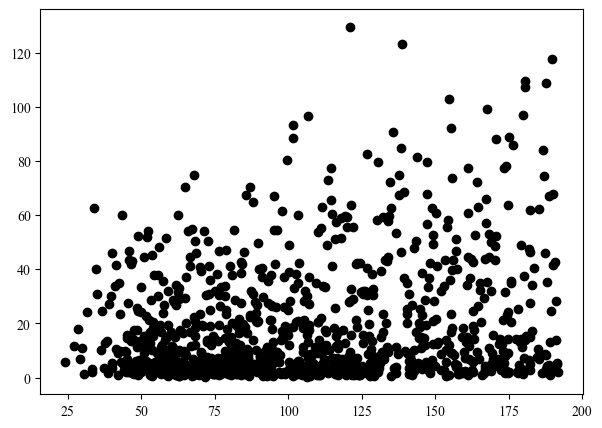

In [29]:
fig,ax = plt.subplots(figsize=(7,5))

ax.plot(Ys[zone],Areas[zone],'ko')

In [241]:
np.sort(np.random.random(10))

array([0.01663939, 0.04757666, 0.05007109, 0.10494533, 0.17826871,
       0.25350629, 0.31025045, 0.45707378, 0.63911918, 0.98636741])

In [55]:
Ys[zone]

array([189.82751818, 191.44879465, 189.05894654, 186.37179581,
       187.56100306, 180.67496465, 183.00427962, 185.4624775 ,
       188.71161801, 189.94322745, 181.78035983, 182.80131417,
       190.06753634, 180.56746402, 178.12261897, 180.01300652,
       189.77647278, 188.18276342, 182.43377062, 186.55570223,
       184.72189395, 180.89699141, 188.71450256, 182.15725753,
       180.51011781, 180.1289617 , 175.71548781, 170.35229576,
       171.79048261, 175.17678692, 180.16231228, 174.76601671,
       173.56097474, 173.63636993, 174.18768567, 173.1871496 ,
       169.08971506, 167.04099697, 165.57490395, 162.74583371,
       166.96667141, 168.87626721, 165.29085107, 168.24735798,
       166.06904692, 170.83827018, 166.58932612, 163.24712354,
       160.85672401, 164.42054137, 179.85071767, 173.96851936,
       176.33169006, 168.99347209, 165.08280315, 167.83285041,
       161.1928011 , 162.02401761, 159.45120709, 179.4690848 ,
       177.7372056 , 175.92433   , 167.38403698, 173.77

In [56]:
np.logical_and(Ys[zone]>30,Ys[zone]<50)

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

[ 10.  30.  50.  70.  90. 110. 130. 150. 170. 190.]
[False False False False False False False False False False]
[ True  True  True  True  True False  True False False False]
[ True  True  True  True  True  True  True False False False]
[ True  True  True  True  True  True  True  True False False]
[ True  True  True  True  True False False False False False]
[ True  True  True  True  True False False False False False]
[ True  True  True  True  True  True  True False False False]
[ True  True  True  True  True  True False False False False]
[ True  True  True  True False  True False  True False  True]


/var/folders/n6/4xt3dwh16hq1057wx_2rxtqh0000gn/T/ipykernel_75009/374270216.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap('viridis')


(0.0, 3.0)

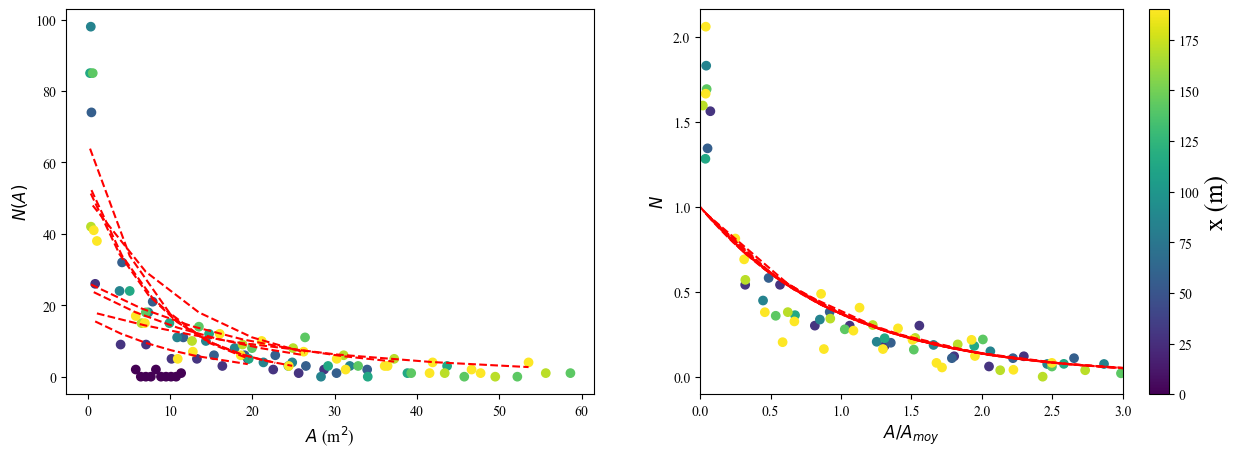

In [65]:
fig,axs = plt.subplots(figsize=(15,5),ncols=2)

ylist = np.linspace(10,190,10)
print(ylist)

cm = plt.cm.get_cmap('viridis')
    
N = len(ylist)-1
bins = np.linspace(0,100,21)

ndistr = 10
Moy = np.zeros((len(ylist)-1,ndistr))
Std = np.zeros((len(ylist)-1,ndistr))

for i,y in enumerate(ylist[:-1]):
#    zone = np.logical_and(np.logical_and(Xs>=Xmin,Xs<Xmax),Ys<Ymax)

    b = np.logical_and(Ys[zone]>=y,Ys[zone]<ylist[i+1]) 
    [n,x] = np.histogram(Areas[zone][b])#,bins=bins)
    xc = (x[:1]+x[:-1])/2
    value = 256*(i/N)
    sc = axs[0].scatter(xc,n,marker='o',cmap=cm,c=value*np.ones(len(xc)),vmin=0,vmax=np.max(ylist))

    #other methods : compute the average by decile of the distribution#keep 20% of the largest flows
    for j in range(10):
        ni =  int(len(Areas[zone][b])*j/10)
        nf =  int(len(Areas[zone][b])*(j+1)/10)
        Alist = np.sort(Areas[zone][b])[ni:nf]
        Moy[i,j] = np.mean(Alist)
        Std[i,j] = np.std(Alist)
    indices = n>3
    print(indices)
    if np.sum(indices)==0:
        continue
    #print(indices)
    p = np.polyfit(xc[indices],np.log(n[indices]),1)
    axs[0].plot(xc[indices],np.exp(np.polyval(p,xc[indices])),'r--')

    xmoy = -1/p[0]
    num = len(Areas[zone][b])
    #print(num)
    #std_3.append(np.std(Areas[zone][b])/np.sqrt(num))
    sc = axs[1].scatter(xc/xmoy,n/np.exp(p[1]),marker='o',cmap=cm,c=value*np.ones(len(xc)),vmin=0,vmax=np.max(ylist))
    axs[1].plot(xc/xmoy,np.exp(np.polyval(p,xc))/np.exp(p[1]),'r--')
    #compute average from the exp. fit
    #moy_3.append(xmoy)
    

graphes.legende('$A$ (m$^2$)','$N(A)$','',ax=axs[0])
graphes.legende('$A/A_{moy}$','$N$','',ax=axs[1])

cbar = plt.colorbar(sc)#,ticks=[-2,-1,0,1])
#cbar.ax.set_yticklabels(['$10^{-2}$','$10^{-1}$','$10^0$','$10^1$'])  
cbar.set_label(r'x (m)', rotation=90,fontsize=18)

xth = np.linspace(0,1,100)
axs[1].plot(xth,np.exp(-xth),'r--')

#axs[0].set_yscale('log')
#axs[1].set_yscale('log')
axs[1].set_xlim([0,3])

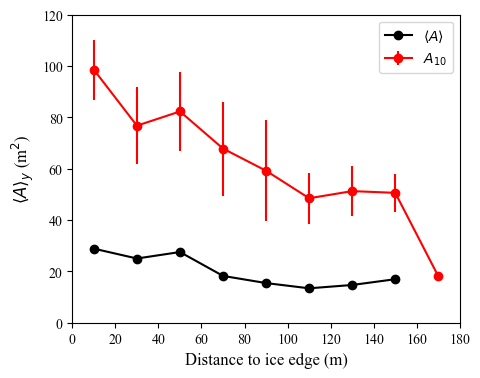

In [74]:
fig,ax = plt.subplots(figsize=(5,4))

yc = (ylist[1:]+ylist[:-1])/2

#for j in range(10):
j=9
ax.errorbar(np.max(ylist)-yc,Moy[:,j],np.asarray(Std[:,j]),marker='o',color='r')
ax.plot(np.max(ylist)-yc,np.mean(Moy,axis=1),marker='o',color='k')


ax.legend([r'$\langle A \rangle$',r'$A_{10}$'])
#ax.errorbar(np.max(ylist)-yc,moy_2,np.asarray(std_2),marker='<',color='b')
#ax.errorbar(np.max(ylist)-yc,moy_3,np.asarray(std_3),marker='>',color='g')

#ax.set_yscale('log')
ax.set_xlim([0,180])
ax.set_ylim([0,120])

figs = graphes.legende('Distance to ice edge (m)',r'$\langle A \rangle_{y}$ (m$^2$)','')
graphes.save_figs(figs,savedir=savefolder,overwrite=True,prefix='Largest_floes_10p_')

In [ ]:
fig,ax = plt.subplots(figsize=(5,4))

yc = (ylist[1:]+ylist[:-1])/2

#for j in range(10):
j=9
ax.errorbar(np.max(ylist)-yc,np.sqrt(Moy[:,j]),np.sqrtnp.asarray(Std[:,j]),marker='o',color='r')
ax.plot(np.max(ylist)-yc,np.mean(Moy,axis=1),marker='o',color='k')


ax.legend([r'$\langle A \rangle$',r'$A_{10}$'])
#ax.errorbar(np.max(ylist)-yc,moy_2,np.asarray(std_2),marker='<',color='b')
#ax.errorbar(np.max(ylist)-yc,moy_3,np.asarray(std_3),marker='>',color='g')

#ax.set_yscale('log')
ax.set_xlim([0,180])
ax.set_ylim([0,120])

figs = graphes.legende('Distance to ice edge (m)',r'$\langle A \rangle_{y}$ (m$^2$)','')
graphes.save_figs(figs,savedir=savefolder,overwrite=True,prefix='Largest_floes_10p_')

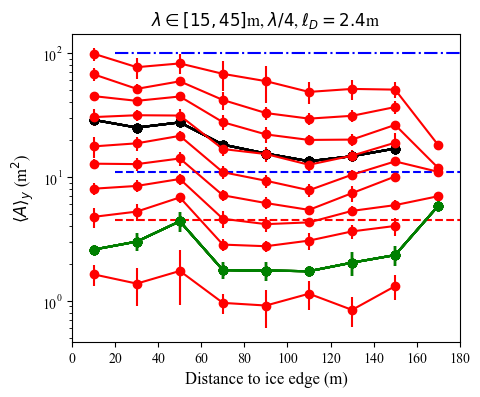

In [62]:
fig,ax = plt.subplots(figsize=(5,4))

yc = (ylist[1:]+ylist[:-1])/2

#for j in range(10):
j=9

jmin = 1
for j in range(10):
    ax.errorbar(np.max(ylist)-yc,Moy[:,jmin],np.asarray(Std[:,jmin]),marker='o',color='g')
    ax.errorbar(np.max(ylist)-yc,Moy[:,j],np.asarray(Std[:,j]),marker='o',color='r')
    ax.plot(np.max(ylist)-yc,np.mean(Moy,axis=1),marker='o',color='k')

#ax.errorbar(np.max(ylist)-yc,moy_2,np.asarray(std_2),marker='<',color='b')
#ax.errorbar(np.max(ylist)-yc,moy_3,np.asarray(std_3),marker='>',color='g')

#ax.set_yscale('log')
ax.set_xlim([0,180])
#ax.set_ylim([0,150])

figs = graphes.legende('Distance to ice edge (m)',r'$\langle A \rangle_{y}$ (m$^2$)','')



Ad = np.pi*(get_ld()/2)**2
lamb1 = 15
lamb2 = 45

Alamb1 = np.pi*(lamb1/8)**2 
Alamb2 = np.pi*(lamb2/8)**2 

ax.plot(yc,np.ones(len(yc))*Ad,'r--')
ax.plot(yc,np.ones(len(yc))*Alamb1,'b--')
ax.plot(yc,np.ones(len(yc))*Alamb2,'b-.')

ax.set_xlim([0,180])
#ax.set_ylim([0,160])
ax.set_yscale('log')

#plt.legend({r'$A_{50}$',r'$A_{90}$',r'$A$',r'$A$',r'$\lambda$ = 45m'})
figs = graphes.legende('Distance to ice edge (m)',r'$\langle A \rangle_{y}$ (m$^2$)',r'$\lambda \in [15,45]$m, $\lambda/4$, $\ell_D = 2.4$m',ax=ax)
#graphes.save_figs(figs,savedir=savefolder,overwrite=True,prefix='Profile_Max_')

In [51]:
def get_ld():
    return 2.4#flexural length measured on field from seismic data

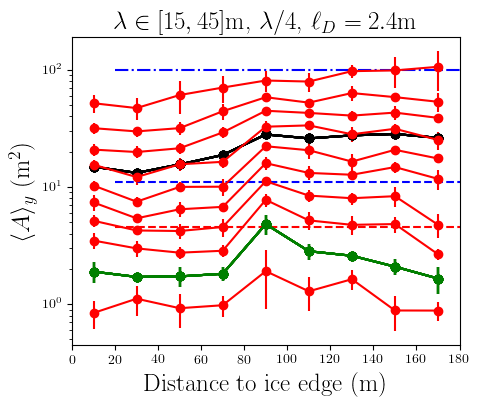

In [309]:
fig,ax = plt.subplots(figsize=(5,4))

yc = (ylist[1:]+ylist[:-1])/2

#for j in range(10):
j=9

jmin = 1
for j in range(10):
    ax.errorbar(np.max(ylist)-yc,Moy[:,jmin],np.asarray(Std[:,jmin]),marker='o',color='g')
    ax.errorbar(np.max(ylist)-yc,Moy[:,j],np.asarray(Std[:,j]),marker='o',color='r')
    ax.plot(np.max(ylist)-yc,np.mean(Moy,axis=1),marker='o',color='k')

#ax.errorbar(np.max(ylist)-yc,moy_2,np.asarray(std_2),marker='<',color='b')
#ax.errorbar(np.max(ylist)-yc,moy_3,np.asarray(std_3),marker='>',color='g')

#ax.set_yscale('log')
ax.set_xlim([0,180])
#ax.set_ylim([0,150])

figs = graphes.legende('Distance to ice edge (m)',r'$\langle A \rangle_{y}$ (m$^2$)','')



Ad = np.pi*(get_ld()/2)**2
lamb1 = 15
lamb2 = 45

Alamb1 = np.pi*(lamb1/8)**2 
Alamb2 = np.pi*(lamb2/8)**2 

ax.plot(yc,np.ones(len(yc))*Ad,'r--')
ax.plot(yc,np.ones(len(yc))*Alamb1,'b--')
ax.plot(yc,np.ones(len(yc))*Alamb2,'b-.')

ax.set_xlim([0,180])
#ax.set_ylim([0,160])
ax.set_yscale('log')

#plt.legend({r'$A_{50}$',r'$A_{90}$',r'$A$',r'$A$',r'$\lambda$ = 45m'})
figs = graphes.legende('Distance to ice edge (m)',r'$\langle A \rangle_{y}$ (m$^2$)',r'$\lambda \in [15,45]$m, $\lambda/4$, $\ell_D = 2.4$m',ax=ax)
#graphes.save_figs(figs,savedir=savefolder,overwrite=True,prefix='Profile_Max_')

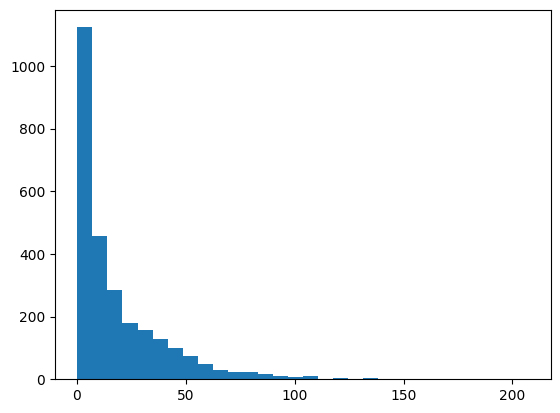

[[ 0.          0.        ]
 [ 0.19993888  0.4890863 ]
 [ 0.47864157  0.59827763]
 [ 0.2241739   1.28982256]
 [ 0.21205639  1.67199197]
 [-0.18782137  2.28164295]
 [-0.3029377   2.29984148]
 [-0.56952288  2.10875688]
 [-0.78157927  1.77435875]
 [-1.09057572  1.51957918]
 [-0.93910687  0.97362278]
 [-0.58769914  0.40946761]
 [ 0.          0.        ]]


2.068046365408019

In [51]:
import stephane.sdeform.spherical as sphere



4.387175067677163e-09

In [7]:
header = data[0]
print(header)

datas={}
for key in header:
    datas[key]=[]
    
for i in range(1,len(data)):
    for j,key in enumerate(header):
        datas[key].append(float(data[i][j]))

['y', 'x', 'area', 'perimeter', 'frame', 'major_axis', 'minor_axis', 'particle']


In [10]:
#print(len(particles))

4568


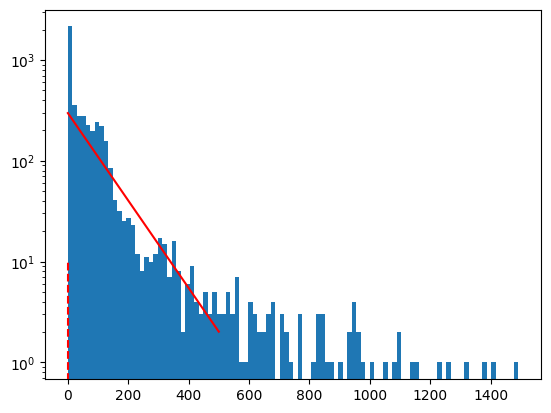

In [16]:
n = int(np.max(datas['particle']))

bins = np.arange(1,n+1)
[n,x] = np.histogram(datas['particle'],bins=np.arange(n+1)+1/2)
#plt.plot(bins,n,'o')
#plt.ylim([0,100])

fig = plt.hist(n,100)
plt.yscale('log')
t0 = 0
plt.plot([t0,t0],[0,10],'r--')


t = np.linspace(1,500,500)
t0 = -100
A = 300
plt.plot(t,A*np.exp(t/t0),'r-')

particles = np.where(n>t0)[0]+1
print(np.sum(n>t0))

In [199]:
print(len(indices[0]))

101


In [13]:
#lifetime = np.sum(datas['particle']==particle)
#print(lifetime)

8
152
160
236
256
326
418
424
441
445
455
519
521
553
563
564
565
569
574
578
579
581
583
594
598
601
606
610
614
617
629
630
631
633
634
636
642
645
653
654
657
660
661
663
664
665
666
669
671
674
675
677
685
697
715
731
737
741
743
746
750
751
758
762
767
769
777
784
787
789
792
793
798
805
808
814
816
817
818
819
823
824
829
832
838
845
866
867
868
870
872
914
922
933
938
947
957
958
962
966
973
976
978
990
991
994
1011
1015
1017
1019
1023
1027
1037
1044
1046
1049
1054
1056
1058
1060
1062
1072
1073
1074
1075
1078
1094
1096
1097
1116
1118
1119
1124
1128
1138
1142
1143
1151
1153
1157
1166
1167
1174
1186
1193
1194
1195
1200
1205
1207
1211
1223
1225
1226
1228
1239
1244
1245
1249
1250
1258
1263
1269
1270
1273
1276
1279
1285
1288
1289
1291
1293
1294
1304
1305
1307
1315
1320
1321
1326
1331
1333
1334
1337
1342
1344
1346
1347
1348
1354
1361
1370
1379
1385
1398
1404
1410
1419
1420
1422
1424
1431
1432
1433
1438
1449
1461
1468
1471
1475
1476
1486
1488
1493
1503
1506
1508
1515
1516
1517
1520
152

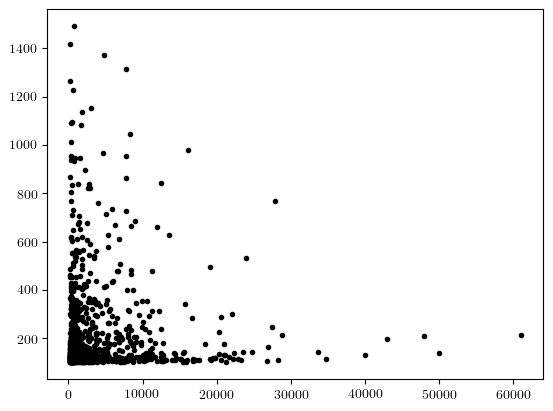

In [191]:
pop=[]

for particle in particles:
    print(particle)
    lifetime = np.sum(datas['particle']==particle)
    
    indices = np.where(datas['particle']==particle)
    lifetime
    t = np.asarray(datas['frame'])[indices]
    A = np.asarray(datas['area'])[indices]
    
    Amean = np.mean(A)
    
    p = {}
    p['particle']=particle
    p['Amean']=Amean
    p['T']=lifetime
    pop.append(p)
    
    plt.plot(Amean,lifetime,'k.')

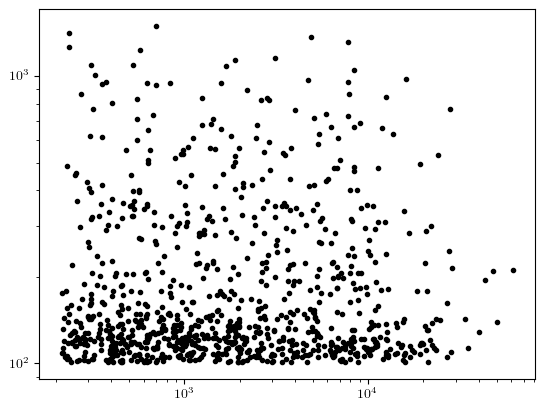

In [241]:
Amean,T = [],[]
for p in pop:
    plt.loglog(p['Amean'],p['T'],'k.')
    Amean.append(p['Amean'])
    T.append(p['T'])

In [244]:
len(datas['particle'])


296318

215.0091743119266
61001.04245283019
4568
4568
4568
4568


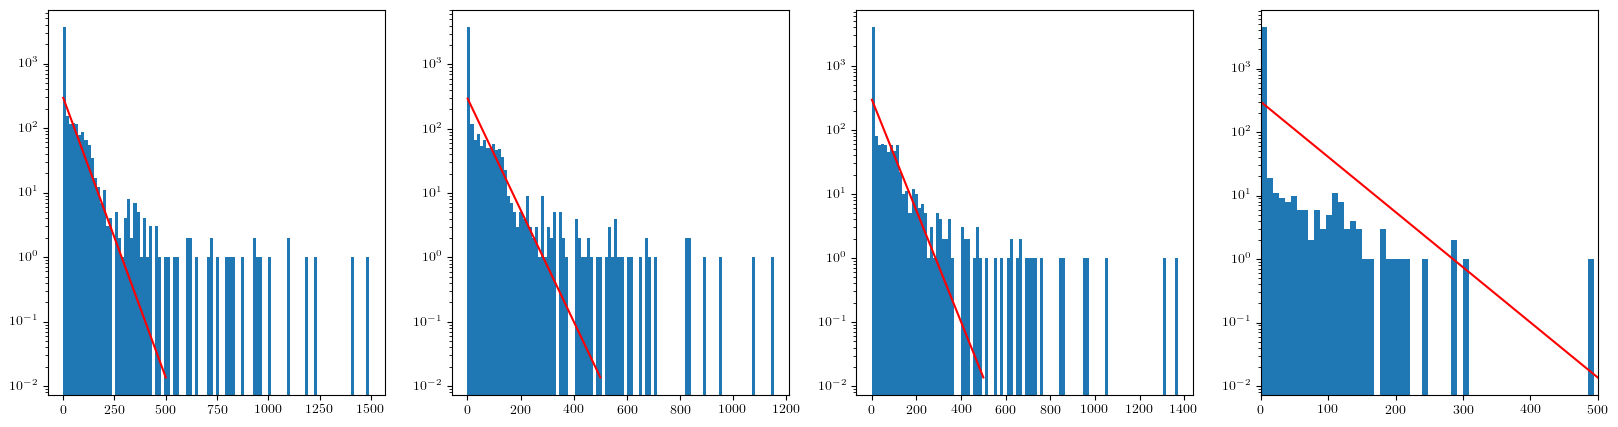

In [258]:
print(np.min(Amean))
print(np.max(Amean))


Abins = np.logspace(np.log10(np.min(Amean)),np.log10(np.max(Amean)),5)


fig,axs = plt.subplots(figsize=(20,5),ncols=4)
for i,Ab in enumerate(Abins[:-1]):
    n = int(np.max(datas['particle']))

    inds = np.logical_and(datas['area']>=Abins[i],datas['area']<Abins[i+1])
    bins = np.arange(1,n+1)
    [n,x] = np.histogram(np.asarray(datas['particle'])[inds],bins=np.arange(n+1)+1/2)
    #plt.plot(bins,n,'o')
    #plt.ylim([0,100])

    axs[i].hist(n,100)
    axs[i].set_yscale('log')
    t0 = 100
    #axs[i].plot([t0,t0],[0,10],'r--')


    t = np.linspace(1,500,500)
    t0 = -50
    A = 300
    axs[i].plot(t,A*np.exp(t/t0),'r-')

    particles = np.where(n>t0)[0]+1
    print(np.sum(n>t0))
    plt.xlim([0,500])

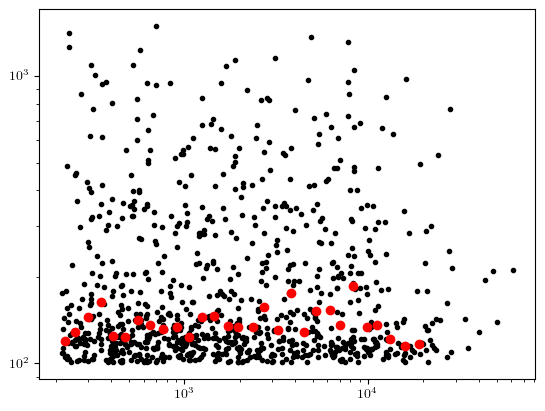

In [221]:
bins = np.logspace(np.log10(2)+2,np.log10(2)+4,30)


[n,x] = np.histogram(Amean,bins=bins)
xc = (x[1:]+x[:-1])/2
plt.loglog(Amean,T,'k.')

Amean = np.asarray(Amean)
T = np.asarray(T)

for i,b in enumerate(bins[:-1]):
    inds = np.logical_and(Amean>bins[i],Amean<=bins[i+1])
    Amoy = np.mean(Amean[inds])
    Tmoy = np.median(T[inds])
    plt.loglog(Amoy,Tmoy,'ro')
#plt.ylim([0,100])

In [150]:
datas.keys()

dict_keys(['y', 'x', 'area', 'perimeter', 'frame', 'major_axis', 'minor_axis', 'particle'])

In [185]:
datas

array([   8,  152,  160,  236,  256,  326,  418,  424,  441,  445,  455,
        519,  521,  553,  563,  564,  565,  569,  574,  578,  579,  581,
        583,  594,  598,  601,  606,  610,  614,  617,  629,  630,  631,
        633,  634,  636,  642,  645,  653,  654,  657,  660,  661,  663,
        664,  665,  666,  669,  671,  674,  675,  677,  685,  697,  715,
        731,  737,  741,  743,  746,  750,  751,  758,  762,  767,  769,
        777,  784,  787,  789,  792,  793,  798,  805,  808,  814,  816,
        817,  818,  819,  823,  824,  829,  832,  838,  845,  866,  867,
        868,  870,  872,  914,  922,  933,  938,  947,  957,  958,  962,
        966,  973,  976,  978,  990,  991,  994, 1011, 1015, 1017, 1019,
       1023, 1027, 1037, 1044, 1046, 1049, 1054, 1056, 1058, 1060, 1062,
       1072, 1073, 1074, 1075, 1078, 1094, 1096, 1097, 1116, 1118, 1119,
       1124, 1128, 1138, 1142, 1143, 1151, 1153, 1157, 1166, 1167, 1174,
       1186, 1193, 1194, 1195, 1200, 1205, 1207, 12

In [151]:
N = np.sum(n>t0)
print(N)

927


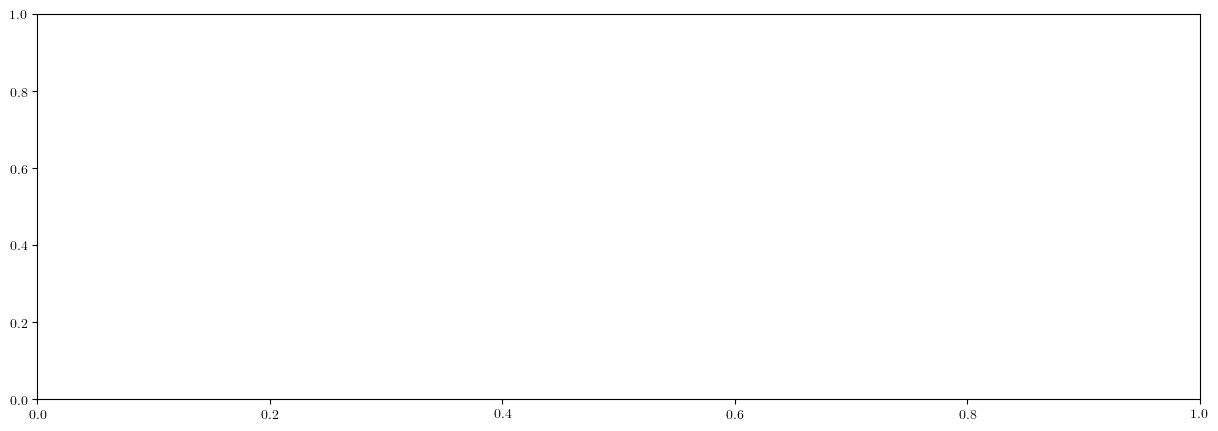

In [152]:
fig,ax = plt.subplots(figsize=(15,5))

P = np.zeros((N,t0))
for i,p in enumerate(particles):
    print(i)
    indices = np.where(datas['particle']==p)
    t = np.asarray(datas['frame'])[indices]
    A = np.asarray(datas['area'])[indices]
    t = t-t[0]
    A = A/A[0]
    #ax.plot(t,A)
    P[i,:]=A[:t0]
    
    #ax.set_ylim([0,3])
    #ax.set_xlim([0,t0])
    
#graphes.legende('','','')

/var/folders/n6/4xt3dwh16hq1057wx_2rxtqh0000gn/T/ipykernel_53450/2005135887.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap('viridis')
/var/folders/n6/4xt3dwh16hq1057wx_2rxtqh0000gn/T/ipykernel_53450/2005135887.py:18: RuntimeWarning: divide by zero encountered in log
  p = np.polyfit(xc[indices],np.log(n[indices]),1)


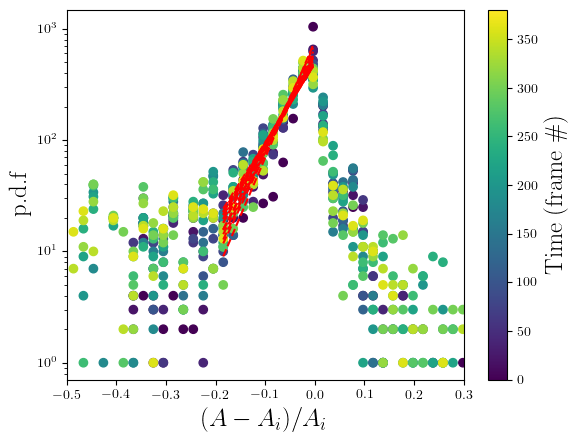

In [99]:
bins = np.linspace(0,3,150)

cm = plt.cm.get_cmap('viridis')
b=20

times = np.arange(int(t0/b))*b
alphas = []
for i in range(int(t0/b)):
    Z = np.reshape(P[:,i*b:(i+1)*b],(b*N,1))
    [n,x]=np.histogram(Z,bins=bins)

    xc = (x[1:]+x[:-1])/2
    xc = xc-1
    sc = plt.scatter(xc,n,marker='o',cmap=cm,c=(i*b)*np.ones(len(xc)),vmin=0,vmax=t0)
        
    indices = np.logical_and(xc<=0,xc>-0.2)
    
    p = np.polyfit(xc[indices],np.log(n[indices]),1)
    plt.plot(xc[indices],np.exp(np.polyval(p,xc[indices])),'r--')
    
    alphas.append(p[0])
#    print(p[0])
    
cbar = plt.colorbar(sc)#,ticks=[-2,-1,0,1])
#cbar.ax.set_yticklabels(['$10^{-2}$','$10^{-1}$','$10^0$','$10^1$'])  
cbar.set_label(r'Time (frame \#)', rotation=90,fontsize=18)

plt.xlim([-0.5,0.3])
plt.yscale('log')

figs = graphes.legende(r'$(A-A_i)/A_i$',r'p.d.f','')
graphes.save_figs(figs,savedir=savefolder)

18.829179254029377


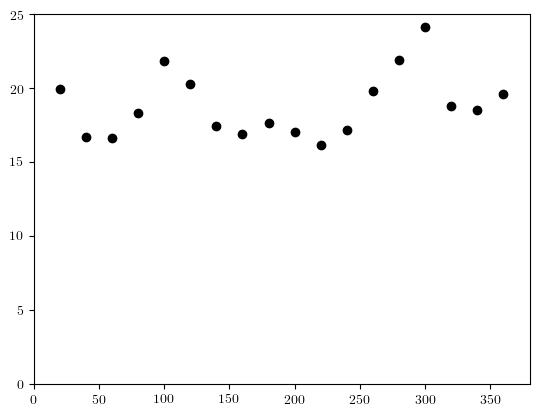

In [96]:
plt.plot(times,alphas,'ko')
plt.axis([0,380,0,25])

print(np.nanmean(alphas))

NameError: name 'N' is not defined

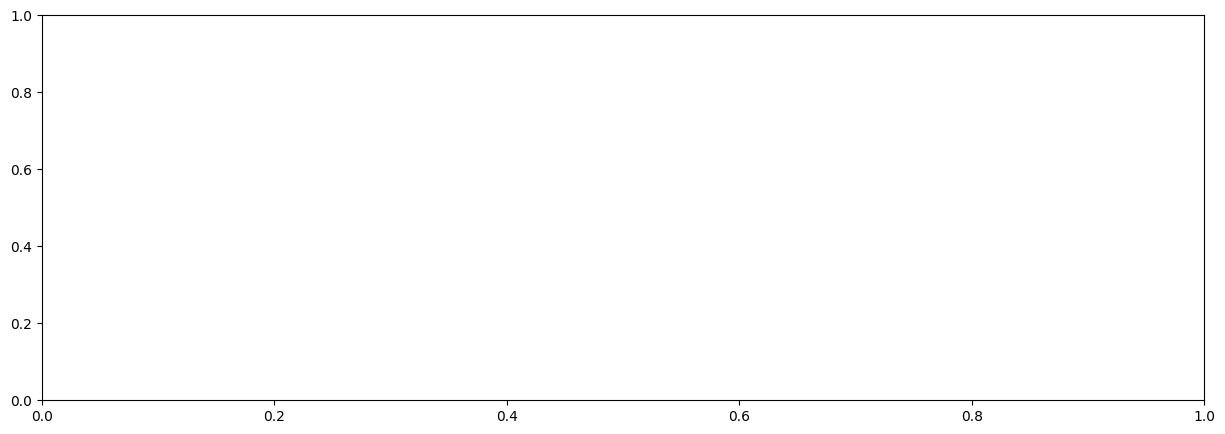

In [9]:
fig,ax = plt.subplots(figsize=(15,5))

P = np.zeros((N,t0))
print(len(particles))
for i,p in enumerate(particles):
    indices = np.where(datas['particle']==p)[0]
    if len(indices)>600:
        print(i,len(indices))
        t = np.asarray(datas['frame'])[indices]
        A = np.asarray(datas['area'])[indices]
        t = t
        A = A#/A[0]
        ax.semilogy(t,A,'.')
        #P[i,:]=A[:t0]
        

        ax.set_ylim([100,10**4])
        ax.set_xlim([0,2400])
#graphes.legende('','','')

In [120]:
events = {}
for i,p in enumerate(particles):
    indices = np.where(datas['particle']==p)[0]
    t = np.asarray(datas['frame'])[indices]
    A = np.asarray(datas['area'])[indices]
    t = t-t[0]
    A = A/A[0]
    inds = np.where((np.diff(A)<-0.1))[0]
    if len(inds)>0 and len(inds)<10:
        events[p]={}
        events[p]['times']=inds
        print(len(inds))
    #P[i,:]=A[:t0]


4
6
1
1
1
2
1
2
5
3
1
1
2
4
1
1
1
1
1
1
9
6
5
1
1
2
7
1
2
2
2
1
1
1
1
2
2
1
3
1
7
1
1
1
4
2
2
1


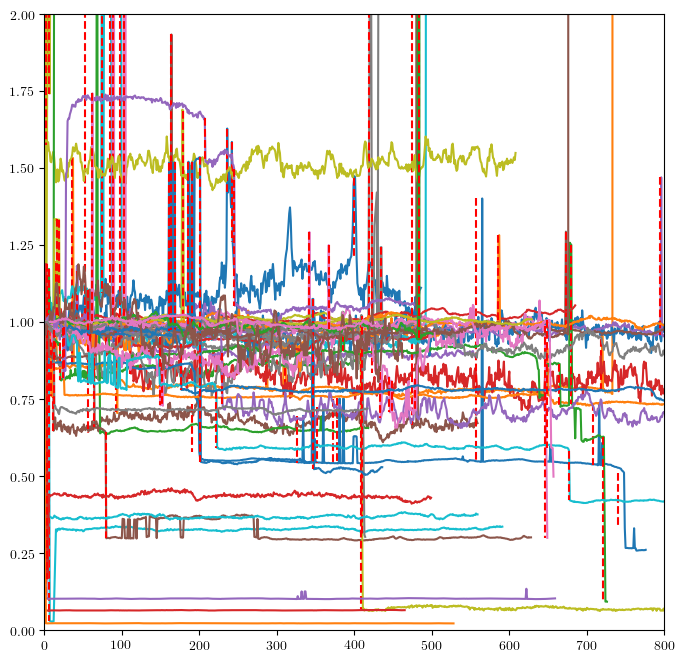

In [124]:
fig,ax = plt.subplots(figsize=(8,8))

for key in events.keys():
    indices = np.where(datas['particle']==key)[0]
    t = np.asarray(datas['frame'])[indices]
    A = np.asarray(datas['area'])[indices]
    t = t-t[0]
    A = A/A[0]
    
    ax.plot(t,A)
    for ti in events[key]['times']:
        ax.plot([ti,ti],[A[ti],A[ti+1]],'r--')
    
    ax.set_ylim([0,2])
    ax.set_xlim([0,800])


0 199900.25 8
1 160563.9 10
2 160728.4 10
3 229749.14285714287 7
4 267086.1666666667 6
5 200351.25 8
6 267144.5 6
7 133796.91666666666 12
8 200539.625 8
9 134071.41666666666 12
10 179246.0 9
11 179369.55555555556 9
12 202324.25 8
13 135337.75 12
14 180564.88888888888 9
15 181187.33333333334 9
16 204655.5 8
17 204956.875 8
18 205543.0 8
19 412165.0 4
20 149897.45454545456 11
21 275272.6666666667 6
22 236506.14285714287 7
23 236546.2857142857 7
24 207251.0 8
25 150615.27272727274 11
26 138259.75 12
27 138390.08333333334 12
28 111118.46666666666 15
29 151658.36363636365 11
30 151905.9090909091 11
31 209261.875 8
32 209286.0 8
33 152098.36363636365 11
34 209543.125 8
35 209370.625 8
36 279521.8333333333 6
37 336010.8 5
38 240188.85714285713 7
39 240079.7142857143 7
40 168161.9 10
41 240111.57142857142 7
42 280326.1666666667 6
43 187171.55555555556 9
44 210723.125 8
45 187164.11111111112 9
46 240778.2857142857 7
47 280568.5 6
48 561170.3333333334 3
49 336869.0 5
50 421066.75 4
51 421250.0 4

384 87711.26315789473 19
385 111128.0 15
386 98065.0 17
387 111155.06666666667 15
388 97954.88235294117 17
389 119108.28571428571 14
390 92654.77777777778 18
391 92608.33333333333 18
392 98066.17647058824 17
393 111206.13333333333 15
394 128325.84615384616 13
395 98267.0 17
396 98343.05882352941 17
397 92882.5 18
398 98447.64705882352 17
399 111617.93333333333 15
400 111684.26666666666 15
401 111742.53333333334 15
402 111731.26666666666 15
403 128897.76923076923 13
404 139768.83333333334 12
405 119900.14285714286 14
406 139838.16666666666 12
407 139982.41666666666 12
408 129219.23076923077 13
409 152603.63636363635 11
410 140016.83333333334 12
411 105088.25 16
412 129211.76923076923 13
413 120124.21428571429 14
414 112161.6 15
415 120060.42857142857 14
416 98864.0 17
417 112076.93333333333 15
418 111967.53333333334 15
419 120065.57142857143 14
420 129349.38461538461 13
421 120037.35714285714 14
422 112099.6 15
423 105144.75 16
424 129322.61538461539 13
425 112228.26666666666 15
426 168

745 34719.35 40
746 34663.875 40
747 31486.18181818182 44
748 30104.739130434784 46
749 32942.09523809524 42
750 32923.95238095238 42
751 31398.659090909092 44
752 31371.613636363636 44
753 32843.09523809524 42
754 32081.81395348837 43
755 31307.954545454544 44
756 29905.369565217392 46
757 29913.152173913044 46
758 29237.127659574468 47
759 29856.08695652174 46
760 29226.978723404256 47
761 29186.23404255319 47
762 29157.468085106382 47
763 29139.659574468085 47
764 27895.081632653062 49
765 28450.854166666668 48
766 26245.05769230769 52
767 27244.56 50
768 27203.5 50
769 26157.615384615383 52
770 26634.37254901961 51
771 25604.56603773585 53
772 25590.33962264151 53
773 25104.944444444445 54
774 23772.43859649123 57
775 22953.35593220339 59
776 23329.137931034482 58
777 22948.728813559323 59
778 22586.016666666666 60
779 22211.344262295082 61
780 22604.3 60
781 23430.603448275862 58
782 22669.2 60
783 22316.475409836065 61
784 23096.762711864405 59
785 21618.698412698413 63
786 22302

1066 7921.649122807017 114
1067 7700.871794871795 117
1068 7611.8983050847455 118
1069 7652.17094017094 117
1070 7763.226086956522 115
1071 7565.28813559322 118
1072 7614.606837606838 117
1073 7664.7844827586205 116
1074 7575.4358974358975 117
1075 7686.539130434782 115
1076 7721.877192982456 114
1077 7633.826086956522 115
1078 7755.672566371682 113
1079 7582.095652173913 115
1080 7429.811965811966 117
1081 7271.5210084033615 119
1082 7361.675213675214 117
1083 7333.17094017094 117
1084 7312.350427350428 117
1085 7144.764705882353 119
1086 6942.4672131147545 122
1087 6818.6612903225805 124
1088 6679.650793650793 126
1089 6647.746031746032 126
1090 6536.5859375 128
1091 6633.230158730159 126
1092 6526.484375 128
1093 6589.708661417323 127
1094 6644.428571428572 126
1095 6581.118110236221 127
1096 6633.714285714285 126
1097 6734.846774193548 124
1098 6837.622950819672 122
1099 6797.674796747968 123
1100 6809.682926829269 123
1101 6754.935483870968 124
1102 6860.991803278688 122
1103 6866

1381 5435.3708609271525 151
1382 5339.058441558442 154
1383 5235.764331210191 157
1384 5222.509554140127 157
1385 5271.064516129032 155
1386 5158.683544303797 158
1387 5188.738853503185 157
1388 5224.641025641025 156
1389 5273.412903225806 155
1390 5248.532051282052 156
1391 5241.0192307692305 156
1392 5200.076433121019 157
1393 5194.796178343949 157
1394 5169.189873417721 158
1395 5178.7594936708865 158
1396 5180.664556962025 158
1397 5163.791139240507 158
1398 5142.405063291139 158
1399 5128.5759493670885 158
1400 5121.955696202532 158
1401 5066.44375 160
1402 5161.481012658228 158
1403 5208.624203821656 157
1404 5332.538961038961 154
1405 5348.451612903225 155
1406 5276.696202531645 158
1407 5399.148387096774 155
1408 5359.248407643312 157
1409 5460.451612903225 155
1410 5460.7307692307695 156
1411 5579.688311688312 154
1412 5635.673202614379 153
1413 5560.554838709678 155
1414 5484.070063694267 157
1415 5516.974358974359 156
1416 5611.0522875817 153
1417 5444.490445859873 157
1418 

1693 3962.933673469388 196
1694 3959.9435897435897 195
1695 3981.979274611399 193
1696 4001.219895287958 191
1697 3992.638743455497 191
1698 3990.1894736842105 190
1699 3985.157894736842 190
1700 4033.3670212765956 188
1701 3966.916230366492 191
1702 4014.5079365079364 189
1703 3969.0523560209426 191
1704 3921.0259067357515 193
1705 3939.53125 192
1706 3968.910994764398 191
1707 3988.1052631578946 190
1708 3965.2722513089006 191
1709 3986.2631578947367 190
1710 4001.804232804233 189
1711 3995.3068783068784 189
1712 3962.952879581152 191
1713 3952.8072916666665 192
1714 4000.8526315789472 190
1715 4004.5526315789475 190
1716 4002.7473684210527 190
1717 4050.9202127659573 188
1718 3987.549738219895 191
1719 3978.9476439790574 191
1720 4036.9148936170213 188
1721 4027.1063829787236 188
1722 3998.253968253968 189
1723 4009.4202127659573 188
1724 4004.478723404255 188
1725 3976.767195767196 189
1726 3880.4715025906735 193
1727 3815.969387755102 196
1728 3777.1414141414143 198
1729 3899.2187

2000 3422.0837004405284 227
2001 3436.265486725664 226
2002 3477.7668161434976 223
2003 3435.222222222222 225
2004 3445.6026785714284 224
2005 3437.6473214285716 224
2006 3358.3815789473683 228
2007 3319.9170305676857 229
2008 3279.307359307359 231
2009 3307.7336244541484 229
2010 3314.7675438596493 228
2011 3318.0616740088108 227
2012 3218.9310344827586 232
2013 3200.1293103448274 232
2014 3192.6233766233768 231
2015 3218.0526315789475 228
2016 3167.5862068965516 232
2017 3191.2608695652175 230
2018 3250.9380530973453 226
2019 3224.7280701754385 228
2020 3185.7130434782607 230
2021 3171.2597402597403 231
2022 3226.3026315789475 228
2023 3261.7433628318586 226
2024 3264.6106194690265 226
2025 3324.2162162162163 222
2026 3262.8849557522126 226
2027 3349.968325791855 221
2028 3387.7 220
2029 3361.4774774774774 222
2030 3358.8333333333335 222
2031 3364.6380090497737 221
2032 3320.6322869955156 223
2033 3315.391891891892 222
2034 3258.6160714285716 224
2035 3232.4285714285716 224
2036 3245

2305 2825.5772357723577 246
2306 2843.8647540983607 244
2307 2806.6072874493925 247
2308 2824.3714285714286 245
2309 2772.8152610441766 249
2310 2729.4880952380954 252
2311 2740.476 250
2312 2735.652 250
2313 2684.6745098039214 255
2314 2715.0438247011953 251
2315 2720.429718875502 249
2316 2724.0725806451615 248
2317 2721.1093117408905 247
2318 2748.3278688524592 244
2319 2764.4609053497943 243
2320 2742.195918367347 245
2321 2776.0329218106995 243
2322 2820.701244813278 241
2323 2779.520325203252 246
2324 2786.216326530612 245
2325 2816.514403292181 243
2326 2822.694214876033 242
2327 2845.733333333333 240
2328 2868.4579831932774 238
2329 2867.4745762711864 236
2330 2815.8410041841003 239
2331 2819.874476987448 239
2332 2819.774058577406 239
2333 2835.924369747899 238
2334 2824.8535564853555 239
2335 2796.589211618257 241
2336 2782.3264462809916 242
2337 2794.8796680497926 241
2338 2800.8166666666666 240
2339 2727.223577235772 246
2340 2717.0243902439024 246
2341 2721.795918367347 24

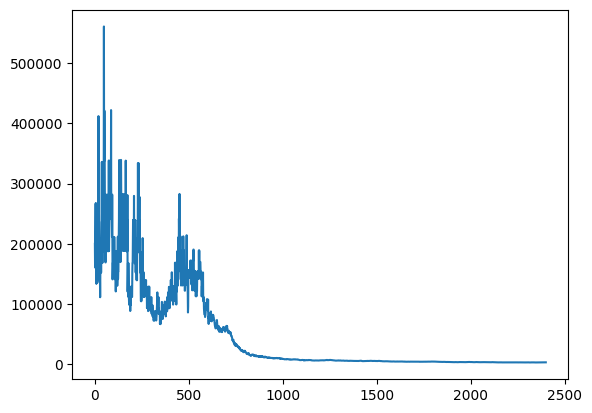

In [18]:
frames = int(np.max(datas['frame']))
A=[]
Nfrag=[]
for i in range(frames):
    inds = (np.asarray(datas['frame'])==i)
    A.append(np.mean(np.asarray(datas['area'])[inds]))
    Nfrag.append(np.sum(inds))
    
    print(i,A[i],Nfrag[i])

plt.plot(A)


[ 0.93860656 -1.74504584]
[ 0.10315744 12.52428892]


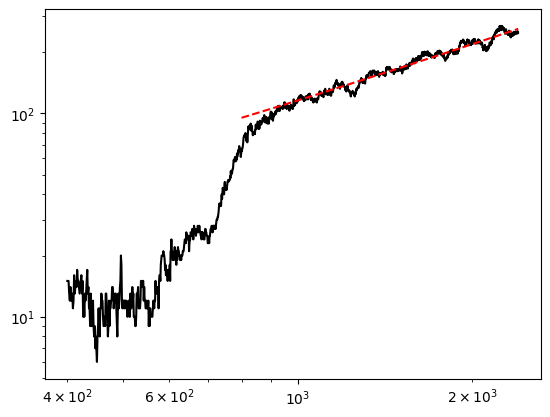

In [17]:
[b,a] = sig.butter(6,0.05,'low')
Nf =  sig.filtfilt(b,a,Nfrag)

t = np.asarray(list(set(datas['frame'])))
#print(t)
tc = (t[1:]+t[:-1])/2
plt.loglog(tc[400:],Nfrag[400:],'k')

x = tc[1000:]
y = Nf[1000:]

p = np.polyfit(np.log(x),np.log(y),1)
print(p)

p2 = np.polyfit(x,y,1)
print(p2)
#plt.xlim([])
tth = np.linspace(800,2400,100)

tref = 10**3
Aref = 1.1*10**2
#plt.plot(tth,Aref*(tth/tref),'r--')
plt.plot(tth,np.polyval(p2,tth),'r--')

[ 0.93860656 -1.74504584]
[ 0.10315744 12.52428892]


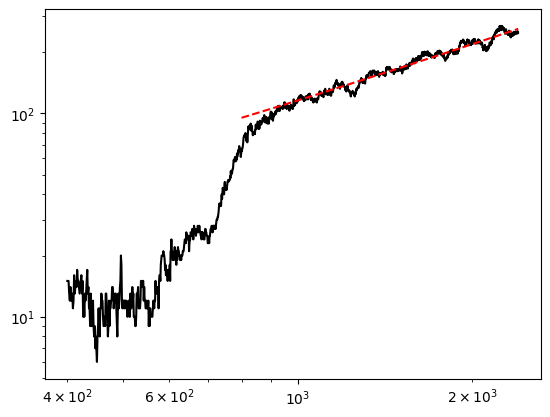

In [13]:
[b,a] = sig.butter(6,0.05,'low')
Nf =  sig.filtfilt(b,a,Nfrag)

t = np.asarray(list(set(datas['frame'])))
#print(t)
tc = (t[1:]+t[:-1])/2
plt.loglog(tc[400:],Nfrag[400:],'k')

x = tc[1000:]
y = Nf[1000:]

p = np.polyfit(np.log(x),np.log(y),1)
print(p)

p2 = np.polyfit(x,y,1)
print(p2)
#plt.xlim([])
tth = np.linspace(800,2400,100)

tref = 10**3
Aref = 1.1*10**2
#plt.plot(tth,Aref*(tth/tref),'r--')
plt.plot(tth,np.polyval(p2,tth),'r--')

[-1.2809451 17.8437766]


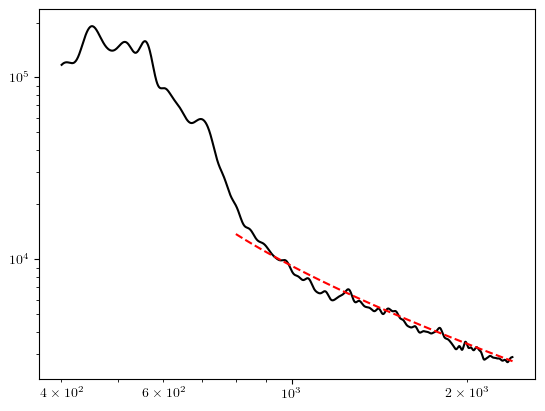

In [135]:
[b,a] = sig.butter(6,0.05,'low')
Af =  sig.filtfilt(b,a,A)

t = np.asarray(list(set(datas['frame'])))
#print(t)
tc = (t[1:]+t[:-1])/2
plt.loglog(tc[400:],Af[400:],'k')

x = tc[1000:]
y = Af[1000:]

p = np.polyfit(np.log(x),np.log(y),1)
print(p)
#plt.xlim([])
tth = np.linspace(800,2400,100)

tref = 10**3
Aref = 0.55*10**4
plt.plot(tth,Aref*((tth-400)/tref)**(-1),'r--')


In [128]:
datas.keys()

dict_keys(['y', 'x', 'area', 'perimeter', 'frame', 'major_axis', 'minor_axis', 'particle'])

In [76]:
(2400-600)/200

9.0

In [118]:
cm(256)

(0.993248, 0.906157, 0.143936, 1.0)

[ 800.  900. 1000. 1100. 1200. 1300. 1400. 1500. 1600. 1700. 1800. 1900.
 2000. 2100. 2200. 2300. 2400.]
[3.01699618e+01 6.93078582e-05]


/var/folders/n6/4xt3dwh16hq1057wx_2rxtqh0000gn/T/ipykernel_58960/1026771697.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap('viridis')


[4.44060511e+01 9.65025467e-05]
[4.82806772e+01 9.33690460e-05]
[6.38195676e+01 1.09530318e-04]
[7.38714045e+01 1.16473599e-04]
[9.15842933e+01 1.36409606e-04]
[9.44568531e+01 1.46327726e-04]
[1.16611961e+02 1.74871421e-04]
[1.30667393e+02 2.00027989e-04]
[1.25402779e+02 1.96163859e-04]
[1.31490063e+02 2.18644944e-04]
[1.43557079e+02 2.45054639e-04]
[1.45191847e+02 2.56286413e-04]
[1.51956444e+02 2.88356708e-04]
[1.67720047e+02 2.81231547e-04]
[1.65523702e+02 2.88001471e-04]


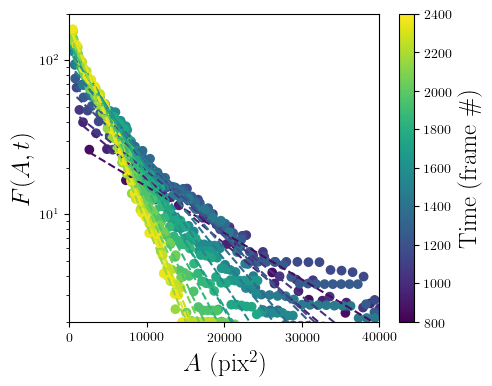

In [152]:
fig,ax = plt.subplots(figsize=(5,4))


np.max(datas['frame'])

tm = 800
tM = 2400
timewindows = np.linspace(tm,tM,17)
print(timewindows)
cm = plt.cm.get_cmap('viridis')

Ntime = []
atime = []
ttime = []
for (tmin,tmax) in zip(timewindows[:-1],timewindows[1:]):
    inds = np.logical_and(datas['frame']>=tmin,datas['frame']<tmax)
    Areas = np.asarray(datas['area'])[inds]
    
    tmean = (tmin+tmax)/2
    [n,x] = np.histogram(Areas,200)
    n = n/(tmax-tmin)
    xc = (x[1:]+x[:-1])/2
    #plt.scatter(xc,np.cumsum(n))
    bins = np.linspace(0,3,150)

    ax.set_ylim([2,2*10**2])
    ax.set_xlim([0,4*10**4])
    
    yc = np.sum(n)-np.cumsum(n)
    def fitfun(x,a,b,):
        return a*np.exp(-b*x)
    pfit,pcov = opt.curve_fit(lambda x,a,b:fitfun(x,a,b),xc,yc,p0=[100,0.0001])
    print(pfit)
    
    yth = fitfun(xc,pfit[0],pfit[1])#,pfit[2])#pfit[0]*np.exp(-pfit[1]*xc)
    color = tmean
    sc = ax.scatter(xc,yc,marker='o',cmap=cm,c=color*np.ones(len(xc)),vmin=tm,vmax=tM)
    ax.plot(xc,yth,'--',color=cm((tmean-tm)/(tM-tm)))
    #plt.xscale('log')
    plt.yscale('log')
    
    Ntime.append(pfit[0])
    atime.append(pfit[1])
    ttime.append(tmean)
    
cbar = plt.colorbar(sc)#,ticks=[-2,-1,0,1])
#cbar.ax.set_yticklabels(['$10^{-2}$','$10^{-1}$','$10^0$','$10^1$'])  
cbar.set_label(r'Time (frame \#)', rotation=90,fontsize=18)

#
figs = graphes.legende(r'$A$ (pix$^2$)',r'$F(A,t)$','')
#graphes.save_figs(figs,savedir=savefolder)



In [129]:
print(ttime)

[850.0, 950.0, 1050.0, 1150.0, 1250.0, 1350.0, 1450.0, 1550.0, 1650.0, 1750.0, 1850.0, 1950.0, 2050.0, 2150.0, 2250.0, 2350.0]


[  0.09265285 -40.45017677]
436.5777946310649


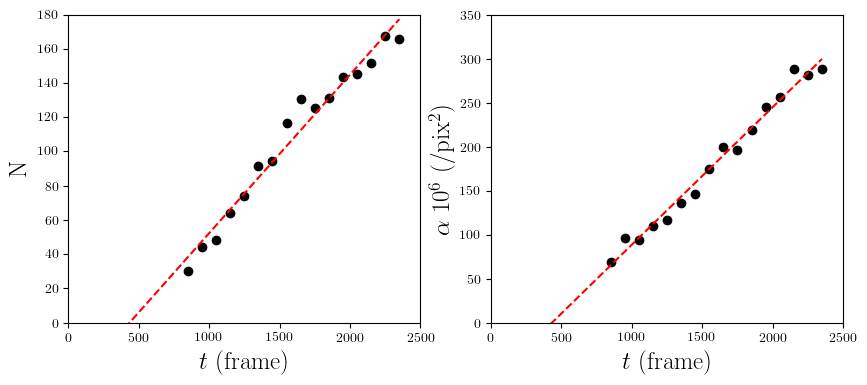

In [153]:
ttime = np.asarray(ttime)
atime = np.asarray(atime)
Ntime = np.asarray(Ntime)

tpart = ttime#-600
fig,axs = plt.subplots(figsize=(10,4),ncols=2)

axs[0].plot(tpart,Ntime,'ko')
p0 = np.polyfit(tpart,Ntime,1)
#p0,pcov = opt.curve_fit(lambda x,a:x*a,tpart,Ntime,p0=0.1)
print(p0)
tth = np.linspace(p0[1],np.max(tpart),100)
axs[0].plot(tth,np.polyval(p0,tth),'r--')
axs[0].set_xlim([0,2500])
axs[0].set_ylim([0,180])

apart = atime*10**6
axs[1].plot(tpart,apart,'ko')

p1 = np.polyfit(tpart,apart,1)
tth = np.linspace(p1[1],np.max(tpart),100)
axs[1].plot(tth,np.polyval(p1,tth),'r--')

#axs[1].plot(ttime,(ttime/1000)**(5/4),'r--')

print(-p0[1]/p0[0])
axs[1].set_xlim([0,2500])
axs[1].set_ylim([0,350])

graphes.legende('$t$ (frame)','N','',ax=axs[0])
figs = graphes.legende('$t$ (frame)',r'$\alpha~10^6$ (/pix$^2$)','',ax=axs[1])
#graphes.save_figs(figs,savedir=savefolder,overwrite=True)



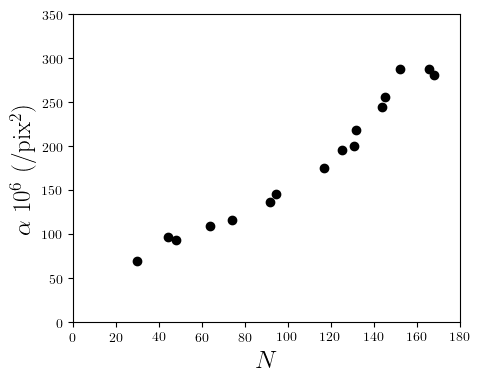

In [164]:
ttime = np.asarray(ttime)
atime = np.asarray(atime)
Ntime = np.asarray(Ntime)

tpart = ttime#-600
apart = atime*10**6

fig,ax = plt.subplots(figsize=(5,4))#,ncols=2)

ax.plot(Ntime,apart,'ko')
ax.set_xlim([0,180])
ax.set_ylim([0,350])


#graphes.legende('$t$ (frame)','N','',ax=axs[0])
figs = graphes.legende('$N$',r'$\alpha~10^6$ (/pix$^2$)','')#,ax=axs[1])
#graphes.save_figs(figs,savedir=savefolder,overwrite=True)



[1200. 1400. 1600. 1800. 2000. 2200. 2400.]


/var/folders/n6/4xt3dwh16hq1057wx_2rxtqh0000gn/T/ipykernel_44349/596123569.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap('viridis')


(0.002, 2)

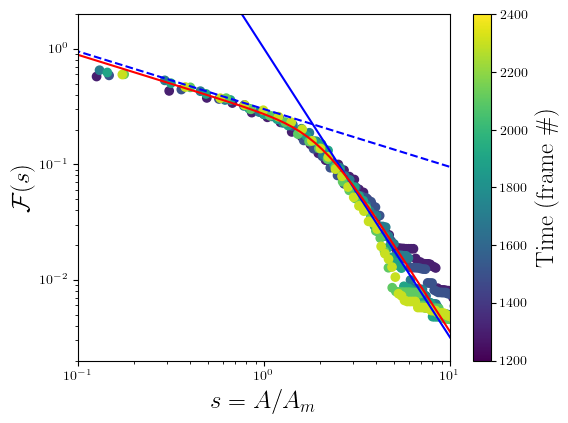

In [236]:
fig,ax = plt.subplots(figsize=(6,4.5))


np.max(datas['frame'])

timewindows = np.linspace(1200,2400,7)
print(timewindows)
cm = plt.cm.get_cmap('viridis')

A0=[]
t = []
for (tmin,tmax) in zip(timewindows[:-1],timewindows[1:]):
    inds = np.logical_and(datas['frame']>=tmin,datas['frame']<tmax)
    Areas = np.asarray(datas['area'])[inds]
    
    tmean = (tmin+tmax)/2
    [n,x] = np.histogram(Areas,200)
    n = n/(tmax-tmin)
    xc = (x[1:]+x[:-1])/2
    #plt.scatter(xc,np.cumsum(n))
    y = (np.sum(n)-np.cumsum(n))/np.sum(n)
    
    sc = ax.scatter(xc/np.mean(Areas),y,marker='o',cmap=cm,c=tmean*np.ones(len(xc)),vmin=1200,vmax=2400)
    A0.append(np.mean(Areas))
    t.append(tmean)
    
    plt.xscale('log')
    plt.yscale('log')
    
    bins = np.linspace(0,3,150)

    ax.set_xlim([0.1,5])
    ax.set_ylim([2*10**(-2),1])
    
    
cbar = plt.colorbar(sc)#,ticks=[-2,-1,0,1])
#cbar.ax.set_yticklabels(['$10^{-2}$','$10^{-1}$','$10^0$','$10^1$'])  
cbar.set_label(r'Time (frame \#)', rotation=90,fontsize=18)


s = np.logspace(-3,1,100)

plt.plot(s,0.3*s**(-1/2),'b--')
plt.plot(s,s**(-2.5),'b-')

# on fit une forme complète
#b négatif
b = -2.5
a = -0.5
s0 = 2
s1 = 0.1
N0 = 0.28##*s1**a
c=2
c2=2
p = ((b-a)*c)
Nth = N0*s**b/((s**p+s0**p)**(1/c))#*(s**(a*c2)+s1**(a*c2))**(1/c2))

plt.plot(s,Nth,'r-')

# b=-2.5
# a=-0.5


figs = graphes.legende(r'$s = A/A_m$',r'$\mathcal{F}(s)$','')
#
#figs = graphes.legende(r'$(A-A_i)/A_i$',r'p.d.f','')
graphes.save_figs(figs,savedir=savefolder,prefix='fit_function_partial_',overwrite=True)
plt.xlim(0.1,10)
plt.ylim(0.002,2)

In [1]:
fig,ax = plt.subplots(figsize=(6,4.5))


np.max(datas['frame'])

timewindows = np.linspace(1200,2400,7)
print(timewindows)
cm = plt.cm.get_cmap('viridis')

A0=[]
t = []
for (tmin,tmax) in zip(timewindows[:-1],timewindows[1:]):
    inds = np.logical_and(datas['frame']>=tmin,datas['frame']<tmax)
    Areas = np.asarray(datas['area'])[inds]
    
    tmean = (tmin+tmax)/2
    [n,x] = np.histogram(Areas,200)
    n = n/(tmax-tmin)
    xc = (x[1:]+x[:-1])/2
    #plt.scatter(xc,np.cumsum(n))
    y = (np.sum(n)-np.cumsum(n))/np.sum(n)
    
    sc = ax.scatter(xc/np.mean(Areas),y,marker='o',cmap=cm,c=tmean*np.ones(len(xc)),vmin=1200,vmax=2400)
    A0.append(np.mean(Areas))
    t.append(tmean)
    
    plt.xscale('log')
    plt.yscale('log')
    
    bins = np.linspace(0,3,150)

    ax.set_xlim([0.1,5])
    ax.set_ylim([2*10**(-2),1])
    
    
cbar = plt.colorbar(sc)#,ticks=[-2,-1,0,1])
#cbar.ax.set_yticklabels(['$10^{-2}$','$10^{-1}$','$10^0$','$10^1$'])  
cbar.set_label(r'Time (frame \#)', rotation=90,fontsize=18)


s = np.logspace(-3,1,100)

plt.plot(s,0.3*s**(-1/2),'b--')
plt.plot(s,s**(-2.5),'b-')

# on fit une forme complète
#b négatif
b = -2.5
a = -0.5
s0 = 2
s1 = 0.1
N0 = 0.28##*s1**a
c=2
c2=2
p = ((b-a)*c)
Nth = N0*s**b/((s**p+s0**p)**(1/c))#*(s**(a*c2)+s1**(a*c2))**(1/c2))

plt.plot(s,Nth,'r-')

# b=-2.5
# a=-0.5


figs = graphes.legende(r'$s = A/A_m$',r'$\mathcal{F}(s)$','')
#
#figs = graphes.legende(r'$(A-A_i)/A_i$',r'p.d.f','')
graphes.save_figs(figs,savedir=savefolder,prefix='fit_function_partial_',overwrite=True)
plt.xlim(0.1,10)
plt.ylim(0.002,2)

NameError: name 'plt' is not defined

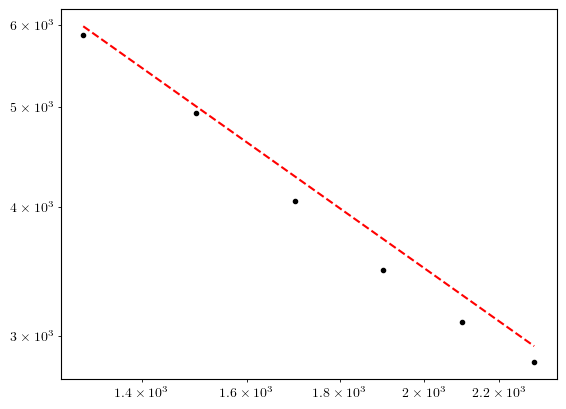

In [120]:
plt.loglog(t,A0,'k.')

t0=1.5*10**3
Aref = 5*10**3
plt.loglog(t,Aref*(np.asarray(t)/t0)**(-1.25),'r--')

[1200. 1400. 1600. 1800. 2000. 2200. 2400.]


/var/folders/n6/4xt3dwh16hq1057wx_2rxtqh0000gn/T/ipykernel_44349/163652934.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap('viridis')


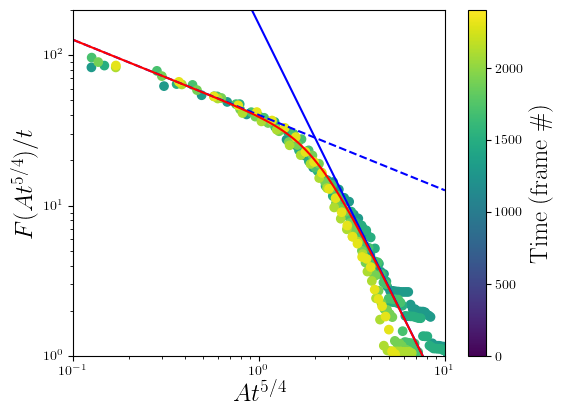

In [234]:
fig,ax = plt.subplots(figsize=(6,4.5))

np.max(datas['frame'])

timewindows = np.linspace(1200,2400,7)
print(timewindows)
cm = plt.cm.get_cmap('viridis')

ts=[]
tmean=[]
As = []

for (tmin,tmax) in zip(timewindows[:-1],timewindows[1:]):
    inds = np.logical_and(datas['frame']>=tmin,datas['frame']<tmax)
    Areas = np.asarray(datas['area'])[inds]
    
    tmean = (tmin+tmax)/2
    ts.append(tmean)
    
    [n,x] = np.histogram(Areas,200)
    n = n/(tmax-tmin)
    xc = (x[1:]+x[:-1])/2
    
    F = (np.sum(n)-np.cumsum(n))
    As.append(np.mean(Areas))
    #plt.scatter(xc,np.cumsum(n))
    sc = ax.scatter(xc/As[0]*(tmean/ts[0])**(1.25),ts[0]*F/tmean,marker='o',cmap=cm,c=tmean*np.ones(len(xc)),vmin=0,vmax=2400)

    plt.xscale('log')
    plt.yscale('log')
    
    bins = np.linspace(0,3,150)

    ax.set_ylim([1,200])
    ax.set_xlim([0.1,10])

cbar = plt.colorbar(sc)#,ticks=[-2,-1,0,1])
#cbar.ax.set_yticklabels(['$10^{-2}$','$10^{-1}$','$10^0$','$10^1$'])  
cbar.set_label(r'Time (frame \#)', rotation=90,fontsize=18)



s = np.logspace(-1,1,100)

# on fit des lois puissances simples
plt.plot(s,40*s**(-1/2),'b--')
plt.plot(s,160*s**(-2.5),'b-')

# on fit une forme complète
#b négatif
b = -2.5
a = -0.5
s0 = 2
s1 = 0.1
N0 = 40##*s1**a
c=2
c2=2
p = ((b-a)*c)
Nth = N0*s**b/((s**p+s0**p)**(1/c))#*(s**(a*c2)+s1**(a*c2))**(1/c2))





plt.plot(s,Nth,'r-')

#
figs = graphes.legende(r'$A t^{5/4}$',r'$F(At^{5/4})/t$','')
graphes.save_figs(figs,savedir=savefolder,prefix='Rescaled_',overwrite=True)

[1200. 1400. 1600. 1800. 2000. 2200. 2400.]


/var/folders/n6/4xt3dwh16hq1057wx_2rxtqh0000gn/T/ipykernel_44349/3254402016.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap('viridis')


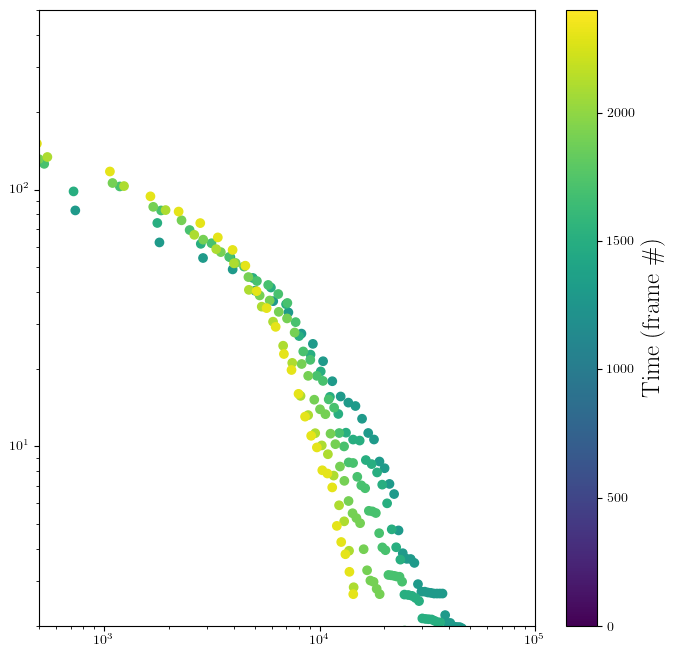

In [138]:
fig,ax = plt.subplots(figsize=(8,8))


np.max(datas['frame'])

timewindows = np.linspace(1200,2400,7)
print(timewindows)
cm = plt.cm.get_cmap('viridis')

for (tmin,tmax) in zip(timewindows[:-1],timewindows[1:]):
    inds = np.logical_and(datas['frame']>=tmin,datas['frame']<tmax)
    Areas = np.asarray(datas['area'])[inds]
    
    tmean = (tmin+tmax)/2
    [n,x] = np.histogram(Areas,200)
    n = n/(tmax-tmin)
    xc = (x[1:]+x[:-1])/2
    #plt.scatter(xc,np.cumsum(n))
    sc = ax.scatter(xc,np.sum(n)-np.cumsum(n),marker='o',cmap=cm,c=tmean*np.ones(len(xc)),vmin=0,vmax=2400)

    plt.xscale('log')
    plt.yscale('log')
    
    bins = np.linspace(0,3,150)

    ax.set_ylim([2,5*10**2])
    ax.set_xlim([500,10**5])

cbar = plt.colorbar(sc)#,ticks=[-2,-1,0,1])
#cbar.ax.set_yticklabels(['$10^{-2}$','$10^{-1}$','$10^0$','$10^1$'])  
cbar.set_label(r'Time (frame \#)', rotation=90,fontsize=18)

#
#figs = graphes.legende(r'$(A-A_i)/A_i$',r'p.d.f','')
#graphes.save_figs(figs,savedir=savefolder)

